<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F05_covariates_and_global_models.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 05 · Three-Tier Exogenous Covariates & Global Cross-Series Models

Real-world enterprise demand and financial forecasting relies on three distinct tiers of exogenous information (`features.py`), each with strict causal availability:
1. **Static Covariates (`features.static_covariates`):** Time-invariant series metadata (`region`, `category`). Target-encoded and one-hot encoded across global panels so cross-series models learn segment-specific elasticities.
2. **Known-Future Covariates (`features.future_covariates`):** Planned promotions (`promo_flag`), scheduled pricing (`price_index`), and calendar holidays known across both historical training and the future forecast horizon $t+1 \dots t+H$.
3. **Observed-Past Covariates (`features.past_covariates`):** Historical weather (`temperature`), foot traffic, or macro indicators observed only up to the forecast origin $t$. To prevent future leakage while forecasting step $h \in [1, H]$, the feature engine automatically shifts `past_covariates` by `exog_lags` $\ge h$.

```mermaid
flowchart TD
    subgraph Tiers["Three-Tier Exogenous Feature Contract (features.py)"]
        T1["static_covariates<br/>region · category<br/>(Time-invariant metadata)"]
        T2["future_covariates<br/>promo_flag · price_index · holidays<br/>(Known in history & future horizon)"]
        T3["past_covariates<br/>temperature + exog_lags {temperature: [7, 14]}<br/>(Observed in history only — lag-shifted)"]
    end
    subgraph Policy["on_unsupported_covariates Policy"]
        P1["fallback (default): strip unsupported tiers & log"]
        P2["error: fail fast at config validation"]
    end
    T1 & T2 & T3 --> Policy --> FIT["Global ML (lightgbm · xgboost · catboost)<br/>& Local Exog (sarimax · prophet)"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Inspect Model Covariate Capabilities & Configure a 3-Tier Global Run

First, let's filter `model_catalog()` to inspect which models support `future_covariates`, `past_covariates`, `static_covariates`, and `global_mode`.

In [3]:
from scale_forecasting import Forecaster, RunConfig, model_catalog

cat = model_catalog()
display(cat[cat["future_covariates"] | cat["past_covariates"] | cat["static_covariates"]][[
    "model", "family", "future_covariates", "past_covariates", "static_covariates", "global_mode", "hybrid_mode"
]])

,model,family,future_covariates,past_covariates,static_covariates,global_mode,hybrid_mode
4,tft,deep_learning,True,True,True,True,False
5,tide,deep_learning,True,True,True,True,False
6,tsmixer,deep_learning,True,True,True,True,False
7,catboost,ml,True,True,False,False,False
8,lightgbm,ml,True,True,False,False,False
9,random_forest,ml,True,True,False,False,False
10,regression_lags,ml,True,True,False,False,False
11,xgboost,ml,True,True,False,False,False
12,auto_arima,statistical,True,True,False,False,False
19,kalman,statistical,True,True,False,False,False


In [4]:
import time

# === Parameters — edit me ===============================================
RUN_NAME = f"nb05 covariates global {int(time.time())}"
SOURCE_TABLE = "source_series_covariates_native"  # or "source_series_covariates_iceberg"
MODELS = ["tide", "tsmixer", "lightgbm", "xgboost", "theta"]
HORIZON = 14
SERIES_LIMIT = 20
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="vertex",
    data={
        "source_table": SOURCE_TABLE,
        "horizon": HORIZON,
        "series_limit": SERIES_LIMIT,
    },
    models=MODELS,
    model_params={
        "tide": {"training_mode": "global", "max_epochs": 15},
        "tsmixer": {"training_mode": "global", "max_epochs": 15},
    },
    compute={
        "families": {
            "deep_learning": {"runtime": "vertex", "hardware": "cpu"},
            "ml": {"runtime": "vertex"},
            "statistical": {"runtime": "vertex"},
        }
    },
    features={
        "holidays": ["US"],
        "static_covariates": ["region", "category"],
        "future_covariates": ["promo_flag", "price_index"],
        "past_covariates": ["temperature"],
        "exog_lags": {"promo_flag": [1, 7], "temperature": [7, 14]},
        "on_unsupported_covariates": "fallback",
    },
    backtest={"enabled": True, "n_folds": 2, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ["inverse_error", "nnls"]},
)

forecaster = Forecaster(cfg, settings=settings)
print("run_id:", forecaster.run_id)
display(forecaster.explain(validate_data=False))

run_id: nb05-covariates-global-1791144913-6614266f6e2e


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb05-covariates-global-1791144913-6614266f6e2e,statistical,sf-nb05-covariates-global-1791144913-6614266f6...,vertex,n2-standard-8,1,cpu,None,theta,theta:local,20,2,20,"future(2), past(1), static(2)",
1,nb05-covariates-global-1791144913-6614266f6e2e,ml,sf-nb05-covariates-global-1791144913-6614266f6...,vertex,n2-standard-8,1,cpu,None,"lightgbm, xgboost","lightgbm:local, xgboost:local",20,2,40,"future(2), past(1), static(2)",
2,nb05-covariates-global-1791144913-6614266f6e2e,deep_learning,sf-nb05-covariates-global-1791144913-6614266f6...,vertex,n2-standard-8,1,cpu,None,"tide, tsmixer","tide:global, tsmixer:global",20,2,40,"future(2), past(1), static(2)",
3,nb05-covariates-global-1791144913-6614266f6e2e,ensemble,sf-nb05-covariates-global-1791144913-6614266f6...,bigquery,sql,1,sql,None,"ensemble_inverse_error, ensemble_nnls",barrier,20,2,40,"future(2), past(1), static(2)",sf-nb05-covariates-global-1791144913-6614266f6...


## Act 3 · Launch & Monitor Live (`forecaster.run_live()`)

Notice in the `explain()` table above that:
- The `deep_learning` family (`tide`, `tsmixer`) runs in **`global`** cross-series mode using all three covariate tiers (`future`, `past`, `static`).
- The `ml` family (`lightgbm`, `xgboost`) runs in **`local`** mode using `future_covariates` and lag-shifted `past_covariates`.
- The `statistical` family (`theta`) automatically strips unsupported covariates under `on_unsupported_covariates='fallback'`.

Completed nb05-covariates-global-1791144913-6614266f6e2e: status=COMPLETED, runtime=994.5s


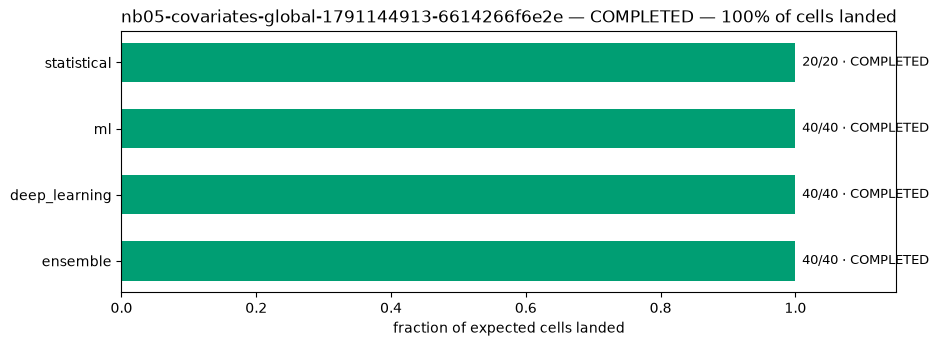

In [5]:
result = forecaster.run_live(poll_s=15.0, probe=True)
print(f"Completed {result.run_id}: status={result.status}, runtime={result.runtime_seconds:.1f}s")

## Act 4 · Review Leaderboard, Interval Calibration & Exogenous Forecast Attribution

Let's compare the global and covariate-aware models against the univariate baseline on the leaderboard, inspect conformal interval calibration by horizon step (`forecaster.plot_calibration()`), and decompose the `lightgbm` forecast into its structural trend, seasonality, and exogenous covariate contributions (`promo_flag`, `price_index`, `temperature`) via `forecaster.plot_forecast_explanation()`.

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,ensemble_inverse_error,ensemble,True,34432fdde9fa,ensemble,20,wape,0.406169,0.137960,...,12.510597,17.542521,NaN,NaN,NaN,NaN,1.0,280,0.024038,0.055875
1,2,theta,statistical,False,None,vertex,20,wape,0.430206,0.155773,...,14.755309,19.577359,0.991071,170.476561,3.662626,2.487433,1.0,280,NaN,NaN
2,3,ensemble_nnls,ensemble,True,34432fdde9fa,ensemble,20,wape,0.432475,0.145220,...,12.810496,18.003265,NaN,NaN,NaN,NaN,0.0,280,-0.002269,-0.005274
3,4,tsmixer,deep_learning,False,None,vertex,20,wape,0.441163,0.214435,...,20.500132,26.225745,0.816071,110.560819,1.899633,1.899633,1.0,280,NaN,NaN
4,5,lightgbm,ml,False,None,vertex,20,wape,0.444321,0.144800,...,13.657062,18.708318,0.237500,104.295213,4.395991,2.331626,1.0,280,NaN,NaN
5,6,xgboost,ml,False,None,vertex,20,wape,0.446640,0.151259,...,13.162259,18.580552,0.164286,108.298528,4.161158,4.282682,1.0,280,NaN,NaN
6,7,tide,deep_learning,False,None,vertex,20,wape,0.461806,0.169715,...,15.458432,20.967358,0.841071,94.894177,1.950581,1.950581,1.0,280,NaN,NaN


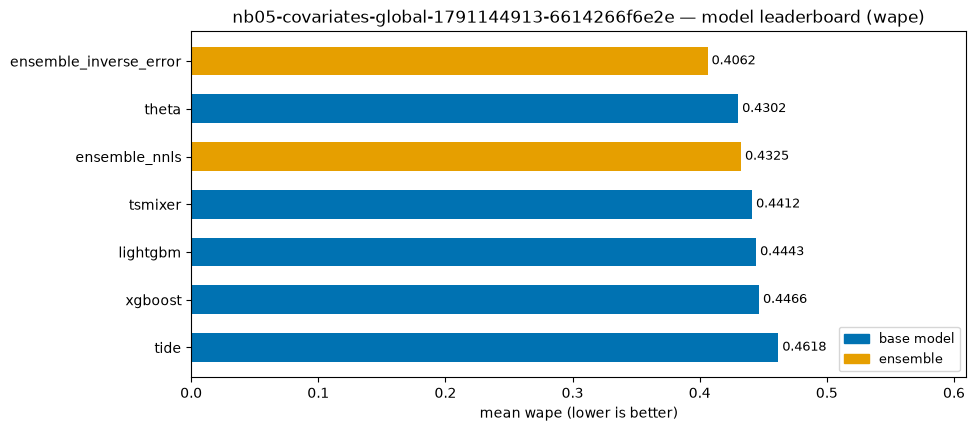

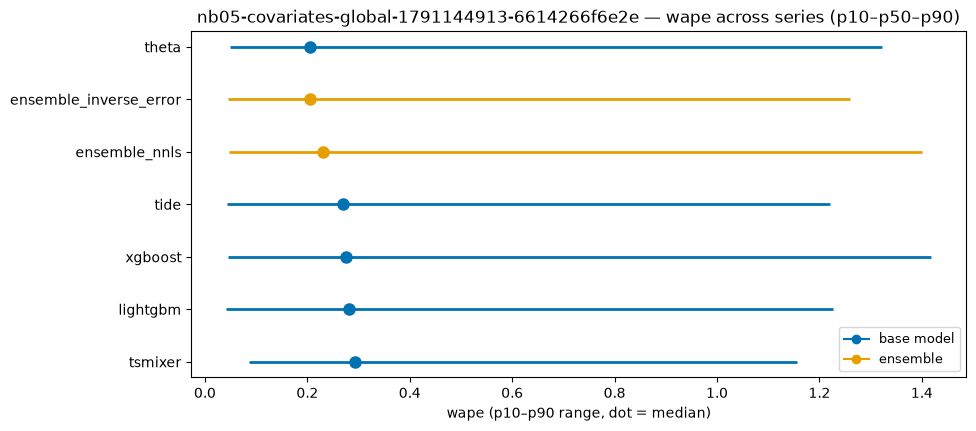

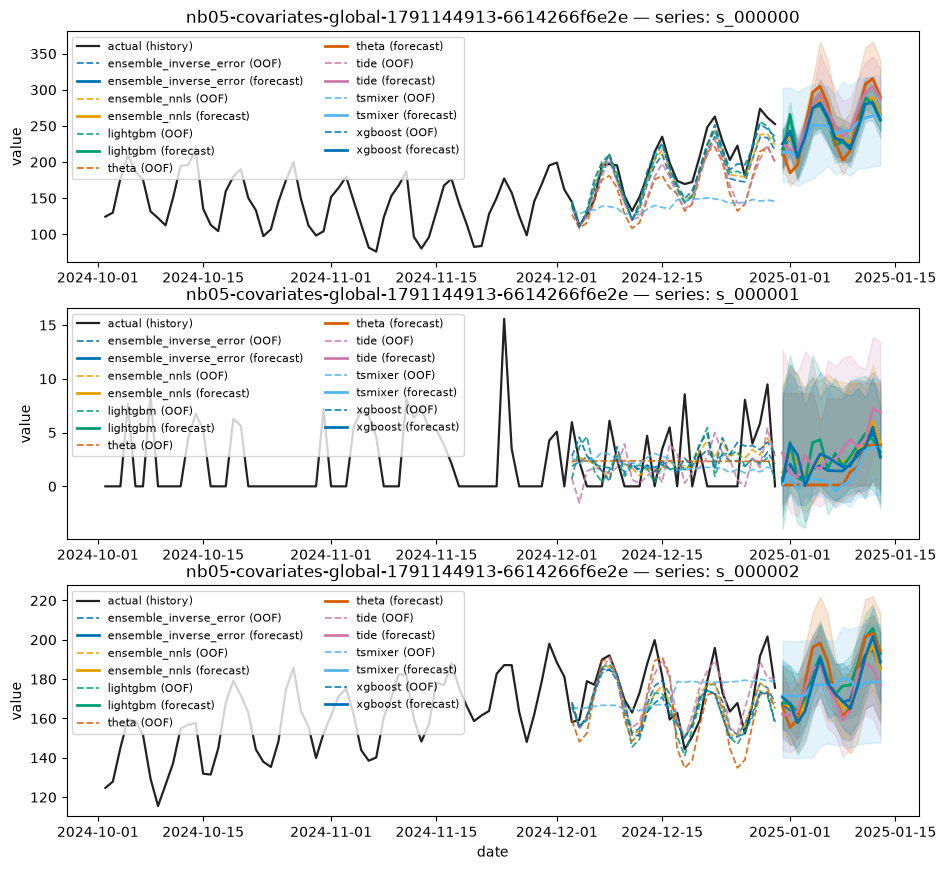

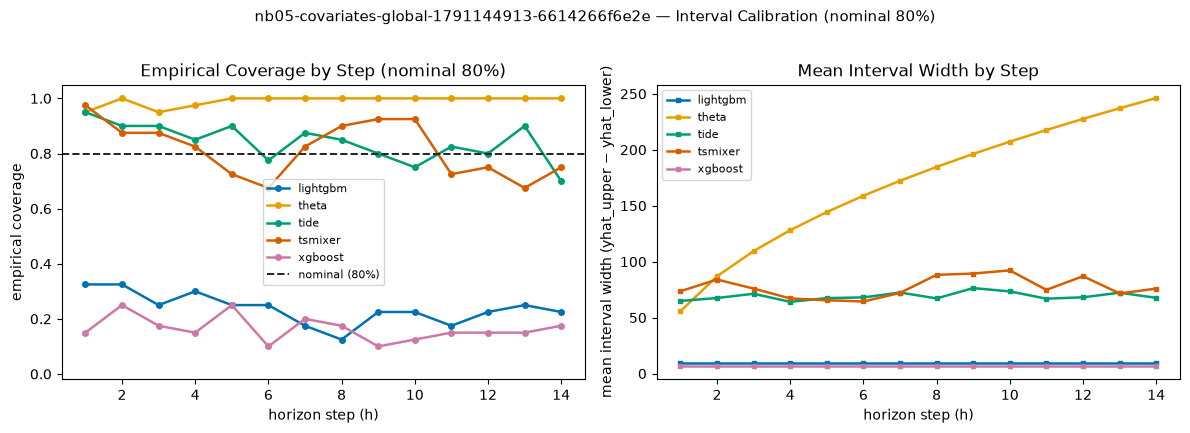

,ts_id,model_type,segment,ds,y_true,yhat,yhat_lower,yhat_upper,trend_baseline,level_shift,seasonal_effect,covariate_effect,oof_residual,interval_width,cov_promo_flag,cov_price_index,cov_temperature
124,s_000000,lightgbm,forecast,2025-01-04,NaN,275.075040,244.507923,287.328154,249.533191,72.779333,32.545727,-3.705789,NaN,42.820230,-0.669871,-1.338342,-1.697576
125,s_000000,lightgbm,forecast,2025-01-05,NaN,278.684157,247.957379,301.089794,244.116069,72.779333,39.063253,-3.705789,NaN,53.132415,-0.669871,-1.338342,-1.697576
126,s_000000,lightgbm,forecast,2025-01-06,NaN,259.804869,229.611275,282.743690,245.970480,72.779333,20.402427,-3.705789,NaN,53.132415,-0.669871,-1.338342,-1.697576
127,s_000000,lightgbm,forecast,2025-01-07,NaN,223.414274,198.289640,247.311521,248.326396,72.779333,-19.018635,-3.705789,NaN,49.021881,-0.669871,-1.338342,-1.697576
128,s_000000,lightgbm,forecast,2025-01-08,NaN,228.002887,202.878253,251.900134,250.304848,72.779333,-40.607435,-3.705789,NaN,49.021881,-0.669871,-1.338342,-1.697576
129,s_000000,lightgbm,forecast,2025-01-09,NaN,217.971142,202.830404,241.970415,250.507421,72.779333,-35.352640,-3.705789,NaN,39.140011,-0.669871,-1.338342,-1.697576
130,s_000000,lightgbm,forecast,2025-01-10,NaN,255.332401,240.918954,280.058965,250.267611,72.779333,2.967304,-3.705789,NaN,39.140011,-0.669871,-1.338342,-1.697576
131,s_000000,lightgbm,forecast,2025-01-11,NaN,288.924208,274.510762,313.650773,254.743168,72.779333,32.545727,-3.705789,NaN,39.140011,-0.669871,-1.338342,-1.697576
132,s_000000,lightgbm,forecast,2025-01-12,NaN,280.102168,265.688722,304.828732,260.091224,72.779333,39.063253,-3.705789,NaN,39.140011,-0.669871,-1.338342,-1.697576
133,s_000000,lightgbm,forecast,2025-01-13,NaN,258.126200,243.712753,282.852764,270.621244,72.779333,20.402427,-3.705789,NaN,39.140011,-0.669871,-1.338342,-1.697576


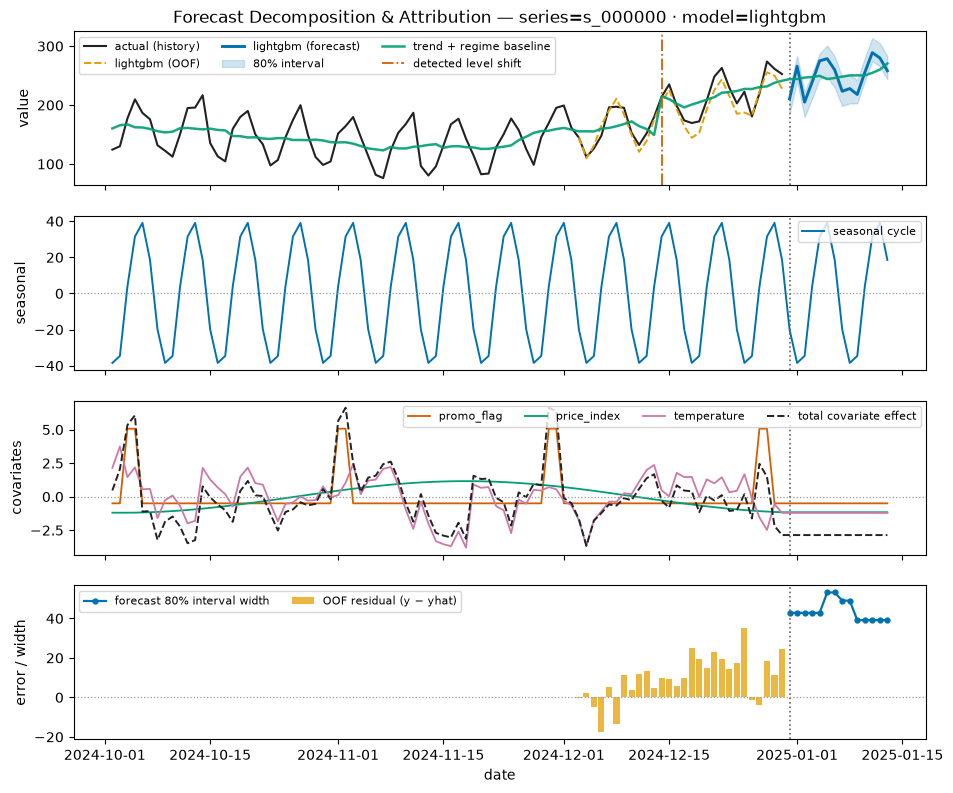

In [6]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard, plot_metric_distribution

display(forecaster.leaderboard_df())

review = forecaster.review_run()
plot_leaderboard(review)
plt.show()

plot_metric_distribution(review)
plt.show()

forecaster.plot_forecasts(history_tail=90)
plt.show()

forecaster.plot_calibration()
plt.show()

exp_df = forecaster.explain_forecast(model_type="lightgbm")
display(exp_df.tail(10))
forecaster.plot_forecast_explanation(model_type="lightgbm", history_tail=90)
plt.show()